## Figure 9. Angular variance by seasons

In [5]:
#Packages:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import scrapbook as sb
import sys
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [6]:
# import plottig functions
from pathlib import Path
import sys
# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.diagnostic_plots import circular_percentile, circular_mean, circular_trend, circular_trend_permutation_test

In [7]:
# ── 1) LOAD GRID ─────────────────────────────────────────────────────────────
shp_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/CONUS_5d_grid.shp"
grid = gpd.read_file(shp_path)

# Make sure we’re in geographic coordinates for Cartopy plotting
grid = grid.to_crs(epsg=4326)

In [8]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
storm_stats = os.listdir(f)
storm_stats = [file for file in storm_stats if file.endswith('.csv')]

centroids = grid.geometry.centroid
xs = centroids.x.values
ys = centroids.y.values

domains = pd.DataFrame(index=grid['D_name'], columns=["x", "y"])
domains["x"] = xs
domains["y"] = ys

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_54038/4044105814.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.geometry.centroid


In [9]:
## function for domain stats
def _month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Fall'


def _compute_variable_stats(df_subset, key, perform_direction_trend=False):
    row = {}

    if key == 'dir':
        directions = df_subset['storm_direction'].dropna()
        if directions.empty:
            return row

        row['mean'] = circular_mean(directions)
        row['median'] = circular_percentile(directions, 50)
        row['p75'] = circular_percentile(directions, 75)
        row['p25'] = circular_percentile(directions, 25)
        row['p5'] = circular_percentile(directions, 5)
        row['p95'] = circular_percentile(directions, 95)
        row['max'] = directions.max()
        row['min'] = directions.min()

        if perform_direction_trend:
            df_year = df_subset.resample('YE').apply(lambda x: x.loc[x['mean_intensity'].idxmax()])
            x = np.arange(len(df_year))
            if len(df_year) > 1 and df_year['storm_direction'].nunique() > 1:
                results = circular_trend_permutation_test(x, df_year['storm_direction'], n_permutations=10000)
                row['trend'] = results['rate_direction_deg']
                row['p_value'] = results['p_value']
            else:
                row['trend'] = np.nan
                row['p_value'] = np.nan

    elif key == 'speed':
        values = df_subset['storm_velocity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'intensity':
        values = df_subset['mean_intensity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'area':
        values = df_subset['area'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'angular_var':
        values = df_subset['angular_variance_weighted'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)

    return row


def compute_stats_by_season(df, key, perform_direction_trend=False):
    season_groups = {'ALL': df}
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        season_groups[season] = df[df['season'] == season]

    seasonal_stats = {}
    for season_name, season_df in season_groups.items():
        seasonal_stats[season_name] = _compute_variable_stats(
            season_df,
            key,
            perform_direction_trend=(perform_direction_trend and season_name == 'ALL'),
        )
    return seasonal_stats


def domain_stats_func(top_storms, perform_direction_trend=False, linear_trajectory_threshold=0.51):
    variable_keys = ['dir', 'speed', 'intensity', 'area', 'angular_var']
    season_keys = ['ALL', 'Winter', 'Spring', 'Summer', 'Fall']
    stats = {key: {season: pd.DataFrame() for season in season_keys} for key in variable_keys}

    for cat in grid['D_name']:
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(f + '/' + cat_file)
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        df = df[df['id'] > (400 - top_storms)].copy()
        # filter by linear trajectory threshold
        if linear_trajectory_threshold is not None:
            df = df[df['angular_variance_weighted'] < linear_trajectory_threshold]

        # get the date from the domain name
        df.index = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
        df.drop(columns=['storm_event'], inplace=True)
        df = df.sort_values(by=df.index.name)
        df['season'] = df.index.month.map(_month_to_season)

        domain_x = domains.loc[cat]['x']
        domain_y = domains.loc[cat]['y']

        for key in variable_keys:
            seasonal_stats = compute_stats_by_season(
                df,
                key,
                perform_direction_trend=perform_direction_trend,
            )

            for season_name, values in seasonal_stats.items():
                for stat_name, stat_value in values.items():
                    stats[key][season_name].loc[cat, stat_name] = stat_value
                stats[key][season_name].loc[cat, 'centroid_x'] = domain_x
                stats[key][season_name].loc[cat, 'centroid_y'] = domain_y

    for key in variable_keys:
        for season_name in season_keys:
            stats[key][season_name].reset_index(inplace=True)
            stats[key][season_name].rename(columns={'index': 'Domain'}, inplace=True)

    return stats

In [15]:
from scipy.stats import gaussian_kde
import matplotlib.patheffects as pe
import warnings

def plot_density_seasons_ax(ax, data, bw=0.5, value_col=None):
    """
    Plot seasonal KDE curves on an existing axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis where the seasonal KDEs are drawn.
    data : dict or pandas.DataFrame or array-like
        Seasonal data as:
        - dict: {"Winter": values, "Spring": values, ...}
        - DataFrame with a "season" column and a numeric value column
        - array-like: treated as a single "ALL" season
    bw : float, optional
        Bandwidth passed to gaussian_kde.
    value_col : str, optional
        Name of numeric column when data is a DataFrame.
    """
    xmin, xmax = ax.get_xlim()

    season_order = ["Winter", "Spring", "Summer", "Fall"]
    season_colors = {
        "Winter": "#2181BD",
        "Spring": "#90EE90",
        "Summer": "#FFD700",
        "Fall": "#FF8C00",
    }
    
    # Build season->values mapping
    season_data = {}
    if isinstance(data, dict):
        for season in season_order:
            if season in data:
                season_data[season] = np.asarray(data[season], dtype=float)
    elif isinstance(data, pd.DataFrame):
        if "season" in data.columns:
            if value_col is None:
                numeric_cols = [c for c in data.columns if c != "season" and np.issubdtype(data[c].dtype, np.number)]
                if not numeric_cols:
                    warnings.warn("DataFrame has no numeric column to plot.")
                    return
                value_col = numeric_cols[0]
            for season in season_order:
                season_data[season] = data.loc[data["season"] == season, value_col].to_numpy(dtype=float)
        else:
            if value_col is None:
                numeric_cols = [c for c in data.columns if np.issubdtype(data[c].dtype, np.number)]
                if not numeric_cols:
                    warnings.warn("DataFrame has no numeric column to plot.")
                    return
                value_col = numeric_cols[0]
            warnings.warn("DataFrame must include a 'season' column for seasonal plotting.")
            return
    else:
        warnings.warn("Input must provide seasonal data (Winter/Spring/Summer/Fall).")
        return

    x_grid = np.linspace(xmin, xmax, 500)
    plotted = []
    global_max = 0.0

    # Seasonal KDE loop
    for season in season_order:
        if season not in season_data:
            continue

        values = np.asarray(season_data[season], dtype=float)
        values = values[np.isfinite(values)]
        if values.size < 2:
            continue

        median_val = float(np.nanmedian(values))
        color = season_colors.get(season, "#4c4c4c")

        try:
            kde = gaussian_kde(values, bw_method=bw)
            density = kde(x_grid)
        except (np.linalg.LinAlgError, ValueError):
            warnings.warn(f"Could not compute KDE for season '{season}'.")
            continue

        ax.plot(x_grid, density, color=color, linewidth=1, alpha=0.95)
        #ax.fill_between(x_grid, density, alpha=0.12, color=color)

        # Median vertical line for each season
        ax.vlines(median_val, ymin=0, ymax=density.max() * 1.05, color=color, linestyle='-', linewidth=0.8, alpha=0.95)

        plotted.append((season, median_val, color))
        global_max = max(global_max, float(np.max(density)))

    if not plotted:
        warnings.warn("No valid seasonal data available for KDE plotting.")
        return

    ax.set_ylim(0, global_max * 1.25)

    # 2x2 median labels above KDE curves
    label_positions = [(0.25, 1.15), (0.75, 1.15), (0.25, 0.95), (0.75, 0.95)]
    for i, (season, median_val, color) in enumerate(plotted[:4]):
        x_ax, y_ax = label_positions[i]
        ax.text(
            x_ax,
            y_ax,
            f"{median_val:.2f}",
            transform=ax.transAxes,
            color=color,
            fontsize=10,
            ha='center',
            va='bottom',
            clip_on=False,
            path_effects=[pe.withStroke(linewidth=0.5, foreground='black')],
        )

    ax.set_facecolor('none')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

def plot_kde_legend(
    ax,
    xlim=(0.0, 1.0),
    percentiles=(5, 25, 50, 75, 95),
    v_max=1.0,
    show_formula=True,
    fill_color="lightblue",
    line_color="black",
    p_median_color="#0072BD",
    p_other_color="#D95319",
    fontsize=12
):
    """Draw a seasonal KDE legend with one probability distribution per season."""
    xmin, xmax = xlim
    xspan = xmax - xmin
    if xspan <= 0:
        xmax = xmin + 1.0
        xspan = 1.0

    x = np.linspace(xmin, xmax, 600)

    # Season-specific synthetic KDE shapes for legend only
    season_specs = [
        ("Winter", "#2181BD", xmin + 0.20 * xspan, 0.10 * xspan),
        ("Spring", "#90EE90", xmin + 0.40 * xspan, 0.09 * xspan),
        ("Summer", "#FFD700", xmin + 0.62 * xspan, 0.10 * xspan),
        ("Fall",   "#FF8C00", xmin + 0.80 * xspan, 0.09 * xspan),
    ]
    season_colors = {
        "Winter": "#2181BD",
        "Spring": "#90EE90",
        "Summer": "#FFD700",
        "Fall": "#FF8C00",
    }

    y_max = 0.0
    for season, color, mu, sigma in season_specs:
        sigma = max(sigma, 1e-9)
        y = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
        y = y / y.max()

        ax.plot(x, y, color=color, lw=1.6, alpha=0.95)
        #ax.fill_between(x, y, 0, color=color, alpha=0.12)

        # Median marker for each seasonal distribution
        ax.vlines(mu, 0, 1.05, colors=color, linestyles='-', linewidth=1.3, alpha=0.95)
        ax.text(
            mu,
            1.08,
            season,
            color=color,
            rotation=45,
            fontsize=fontsize,
            ha='center',
            va='bottom',
            path_effects=[pe.withStroke(linewidth=0.5, foreground='black')],
        )

        y_max = max(y_max, float(np.max(y)))

    # Scale labels at the base
    ax.text(xmin+0.01, -0.03, "0", fontsize=fontsize , ha="left", va="top")
    ax.text(xmax-0.01, -0.03, f"{int(v_max)}", fontsize=fontsize , ha="right", va="top")
    

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.15, max(1.4, y_max + 0.50))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_facecolor((1, 1, 1, 0.4))  # almost transparent background for better visibility if overlaid

In [11]:
## Speed distributions by seasons

In [12]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
storm_stats = os.listdir(f)
storm_stats = [file for file in storm_stats if file.endswith('.csv')]

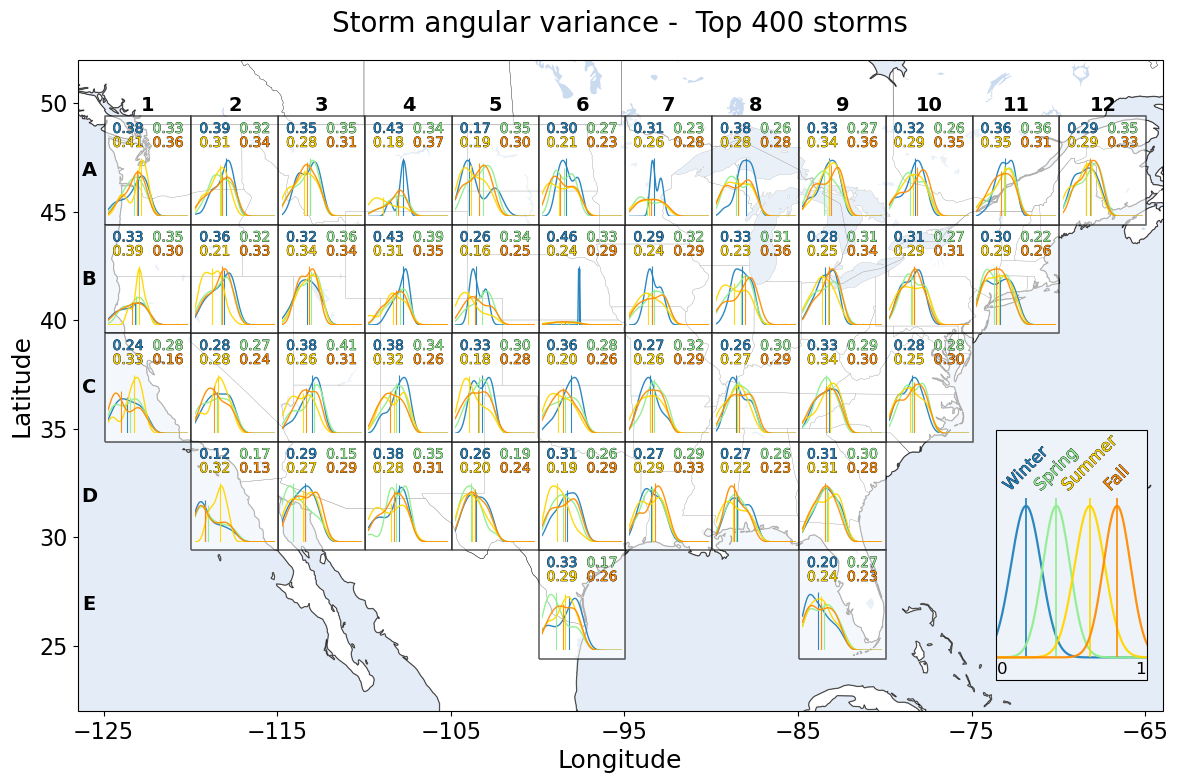

In [16]:
def kde_conus_plot(ax, var_name, x_max,f, domains, grid=None,
                   extent=(-126.5, -64, 22, 52),
                   data_crs=ccrs.PlateCarree(),
                   inset_frac=0.15,
                   top_storms=None,
                   percentiles="5-95"
                   ,percentile_labels=True
                   ,linear_trajectory_threshold=0.51):
    
    var_df = {'speed':'storm_velocity', 'intensity':'mean_intensity', 'angular_var':'angular_variance_weighted'}

    # 1) Map extent in lon/lat -> use PlateCarree!
    ax.set_extent(extent, crs=data_crs)

    # 2) Base map (filled layers first, lines on top)
    ax.add_feature(cfeature.OCEAN, zorder=0, alpha=0.25)
    ax.add_feature(cfeature.LAND, zorder=1, facecolor = 'white', edgecolor="0.5", alpha=0.9)
    ax.add_feature(cfeature.LAKES, zorder=2, alpha=0.5)
    ax.add_feature(cfeature.COASTLINE, zorder=3, linewidth=0.3)
    ax.add_feature(cfeature.BORDERS, zorder=3, linewidth=0.3)
    ax.add_feature(cfeature.STATES, zorder=3, linewidth=0.2, edgecolor="0.2")

    if grid is not None:
        grid.boundary.plot(ax=ax, transform=data_crs, linewidth=1.2, facecolor= 'white', alpha=0.6, color='black', zorder=4)

    # 3) Global x-limits for inset plots
    xmin_data = 0
    xmax_data = x_max
    #xmax_data = 10
    # keep the top storms only in storm stats
    
    # 4) One inset per cell
    for cat in grid['D_name']:
        # parse id & read
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(os.path.join(f, cat_file))
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        if top_storms is not None:
            df = df[df['id'] > 400 - top_storms]
        # filter by linear trajectory threshold
        if linear_trajectory_threshold is not None:
            df = df[df['angular_variance_weighted'] < linear_trajectory_threshold]
        df['date'] = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
        df['season'] = df['date'].dt.month.map(_month_to_season)
        lon = float(domains.loc[cat, 'x'])
        lat = float(domains.loc[cat, 'y'])

        # anchor point in parent axes data coords
        x, y = ax.projection.transform_point(lon, lat, src_crs=data_crs)
        inset_frac=0.7
        axins = inset_axes(
            ax,
            width=0.8,            # fraction of parent axes width
            height=0.7,           # fraction of parent axes height
            loc="center",
            bbox_to_anchor=(x, y-0.5), 
            bbox_transform=ax.transData, # <-- correct transform
            borderpad=0,
        
        )

        # x-range (same across all KDEs)
        axins.set_xlim(xmin_data, xmax_data)

        # seasonal KDE/density function
        plot_density_seasons_ax(
            axins,
            df[["season", var_df[var_name]]],
            value_col=var_df[var_name],
        )

        # sparkline look
        axins.set_xticks([])
        axins.set_yticks([])
        for sp in axins.spines.values():
            sp.set_visible(False)
    #put  labels on top of the grid from 1 to 12
    for i in range(1, 13):
        cell = grid[(grid['row_index']==2.0) & (grid['col_index']==float(i-1))]
        x = (cell.right.values[0] + cell.left.values[0]) / 2  
        y = cell.top.values[0] + 0.5
        ax.text(x, y, str(i), fontsize=14, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())

    # put labels on left side from the grid from A to E
    for i, letter in enumerate(['A', 'B', 'C', 'D', 'E']):

        if i < 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==0.0)]
        elif i == 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==1.0)]
        else:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==5.0)]
        x = grid.loc[26].left - 0.9
        y = (cell.top.values[0] + cell.bottom.values[0]) / 2
        ax.text(x, y, letter, fontsize=14, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())



    # 5) Ticks/labels in lon/lat
    ax.set_xticks(np.arange(-125, -64 + 1, 10), crs=data_crs)
    ax.set_yticks(np.arange(25, 55, 5), crs=data_crs)
    ax.tick_params(axis='both', which='major', labelsize=16)
    title_var = {'speed':'speed', 'intensity':'rainfall intensity', 'angular_var':'angular variance'}
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_ylabel('Latitude', fontsize=18)
    title_tail = f" -  Top {top_storms} storms" if top_storms is not None else ""
    ax.set_title(f"Storm {title_var[var_name]}{title_tail}", fontsize=20, pad=20)



# Example usage
fig = plt.figure(figsize=(14, 10))
parent_projection = ccrs.PlateCarree()
ax = plt.axes(projection=parent_projection)
top_storms = 400
domain_stats_all = domain_stats_func(top_storms, linear_trajectory_threshold=0.51)
storm_stats = [file for file in os.listdir(f) if file.endswith('.csv')]
kde_conus_plot(ax, 'angular_var', 1, f, domains, grid=grid, top_storms=top_storms)

# Add a legend for the KDE inset plots
inset_ax = plt.axes([0.66
                     , 0.2, 0.35, 0.25], projection=ccrs.PlateCarree())
v_max =1
plot_kde_legend(
    inset_ax,
    xlim=(0, 1),
    percentiles=(5, 50,  95),
    v_max=v_max,
    show_formula=False,
    fill_color="lightblue",
    line_color="black",
    p_median_color="#0072BD",
    p_other_color="#D95319",
    fontsize=12
)

In [21]:
domain_stats_all['angular_var']['ALL']

,Domain,mean,median,p75,p25,centroid_x,centroid_y
0,B6,0.409254,0.389467,0.598133,0.207405,-97.437126,41.888331
1,E6,0.432065,0.428610,0.642947,0.223570,-97.437126,26.888331
2,B7,0.445071,0.431139,0.633332,0.243931,-92.437126,41.888331
3,C7,0.442582,0.409772,0.615184,0.255381,-92.437126,36.888331
4,A7,0.401817,0.389099,0.573551,0.211090,-92.437126,46.888331
5,D7,0.417725,0.387717,0.570604,0.229444,-92.437126,31.888331
6,A12,0.513468,0.528408,0.712565,0.317747,-67.437126,46.888331
7,C4,0.576249,0.610507,0.768790,0.412178,-107.437126,36.888331
8,D4,0.520129,0.517970,0.713902,0.349826,-107.437126,31.888331
9,A5,0.397855,0.377849,0.559000,0.191544,-102.437126,46.888331


In [11]:
cat_file = f'storm_properties_A1.csv'
df = pd.read_csv(os.path.join(f, cat_file))
df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
df['date'] = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
df['season'] = df['date'].dt.month.map(_month_to_season)

In [12]:
df['season'] = df['date'].dt.month.map(_month_to_season)

In [13]:
df

,storm_event,storm_direction,storm_velocity,mean_intensity,angular_variance_weighted,area,id,date,season
0,IOWA_Domain.nc_storm_100_20080820.nc,12.180172,7.879314,1.322865,0.475584,81261.211424,100,2008-08-20,Summer
1,IOWA_Domain.nc_storm_101_20150123.nc,-26.892372,8.692427,2.044343,0.585388,75821.580547,101,2015-01-23,Winter
2,IOWA_Domain.nc_storm_102_20190418.nc,-25.202193,4.246733,1.769625,0.532274,45830.934862,102,2019-04-18,Spring
3,IOWA_Domain.nc_storm_103_20040917.nc,-136.129883,4.589789,1.444886,0.896321,111521.727901,103,2004-09-17,Fall
4,IOWA_Domain.nc_storm_104_20211220.nc,102.469779,7.325462,1.558538,0.834565,106902.196099,104,2021-12-20,Winter
...,...,...,...,...,...,...,...,...,...
395,IOWA_Domain.nc_storm_96_20110404.nc,-65.983090,2.522244,1.532432,0.177845,159036.778265,96,2011-04-04,Spring
396,IOWA_Domain.nc_storm_97_20051125.nc,45.330400,5.095791,1.482786,0.530595,118152.183359,97,2005-11-25,Fall
397,IOWA_Domain.nc_storm_98_20150209.nc,104.280144,7.326821,1.685755,0.738126,96907.431517,98,2015-02-09,Winter
398,IOWA_Domain.nc_storm_99_20141113.nc,30.584900,4.670929,1.736525,0.459547,56947.431547,99,2014-11-13,Fall
